In [1]:
import Pkg

Pkg.instantiate()

using Pkg

cd(@__DIR__)
Pkg.activate("../")
Pkg.add(url="https://github.com/tp2750/TuningSystems.jl") 

Pkg.add("DSP")
using DSP
using Dates, SonifSismo, CairoMakie
using Statistics
using WAV
using Seis
using DSP: conv
using TuningSystems
using Test

archive = DataArchive("C:/Users/lucie/Desktop/mtFujiContinuous/mtFujiContinuous")


  Activating project at `c:\Users\lucie\Desktop\sonifSismo.jl-main`
    Updating git-repo `https://github.com/tp2750/TuningSystems.jl`
   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `C:\Users\lucie\Desktop\sonifSismo.jl-main\Project.toml`
    Manifest No packages added to or removed from `C:\Users\lucie\Desktop\sonifSismo.jl-main\Manifest.toml`
   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `C:\Users\lucie\Desktop\sonifSismo.jl-main\Project.toml`
    Manifest No packages added to or removed from `C:\Users\lucie\Desktop\sonifSismo.jl-main\Manifest.toml`


DataArchive("C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\catalog\\h2008", :JST, Hour(9))

In [2]:
push!(LOAD_PATH, "C:/Users/lucie/Desktop/TuningSystems.jl-main/TuningSystems.jl-main/src")

4-element Vector{String}:
 "@"
 "@v#.#"
 "@stdlib"
 "C:/Users/lucie/Desktop/TuningSystems.jl-main/TuningSystems.jl-main/src"

In [3]:
available_stations(archive)
available_channels(archive)

33-element Vector{ChannelAvailability}:
 ChannelAvailability("EV", "FJO", "", "E", [Date("2008-05-25"), Date("2008-05-26"), Date("2008-05-27"), Date("2008-05-28"), Date("2008-05-29"), Date("2008-05-30"), Date("2008-05-31")], ["C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\25\\EV.FJO..E.20080525.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\26\\EV.FJO..E.20080526.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\27\\EV.FJO..E.20080527.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\28\\EV.FJO..E.20080528.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\29\\EV.FJO..E.20080529.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\30\\EV.FJO..E.20080530.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\31\\EV.FJO..E.2008053

In [4]:
events = read_catalog(
    archive;
    start=DateTime(2008, 5, 25),
    stop=DateTime(2008, 5, 31, 23, 59, 59),
    min_magnitude=2.0,
    max_depth=50.0,
)

# Récupération des traces sismiques
traces = read_event(
    archive,
    first(events);
    stations="FUJ",
    channels=["wE", "wN", "wU"],
    processed=true,
    bandpass=(0.5, 15.0),
)

3-element Vector{AbstractTrace}:
 Seis.Trace(EV.FUJ..wE : delta=0.01, b=1378.21, nsamples=12001)
 Seis.Trace(EV.FUJ..wN : delta=0.01, b=1378.21, nsamples=12001)
 Seis.Trace(EV.FUJ..wU : delta=0.01, b=1378.21, nsamples=12001)

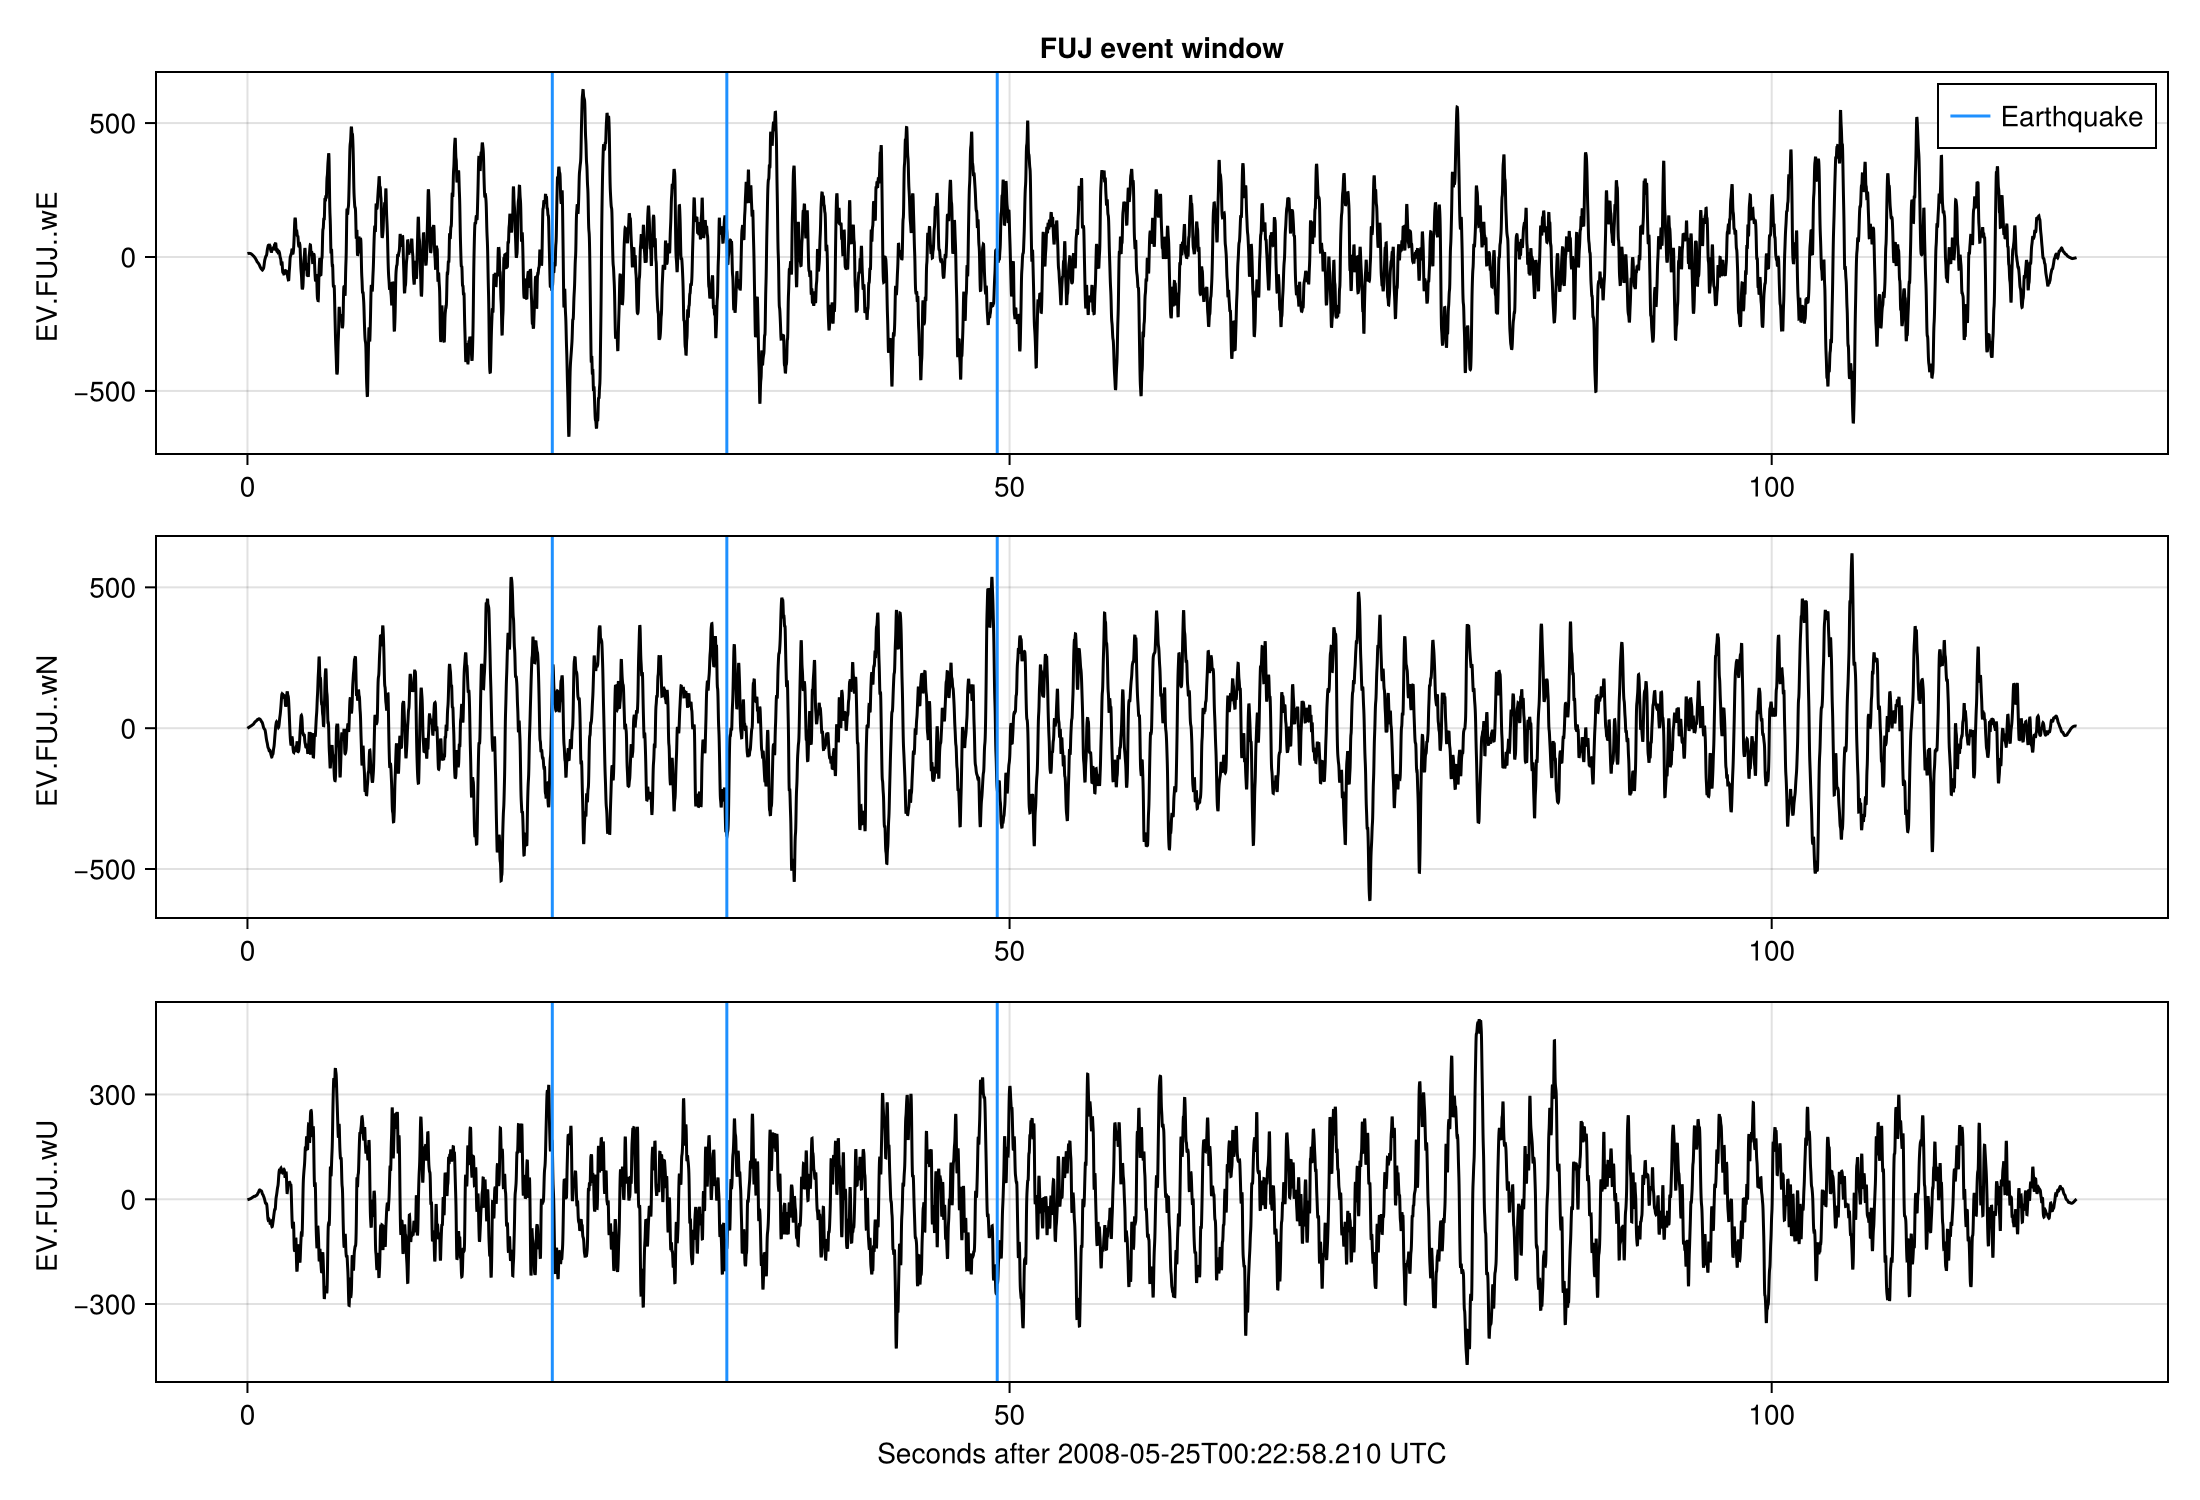

In [5]:
event = first(events)

plot_events = read_catalog(
    archive;
    start=event.origin_time_utc - Second(20),
    stop=event.origin_time_utc + Second(100),
)

# Tracé des traces sismiques en fonction du temps
wavefig = plot_waveforms(
    traces;
    events=plot_events,
    title="FUJ event window",
)
wavefig

In [1]:
fs = 100            # Fréquence d'échantillonnage (100 échantillons par seconde, cohérent avec le delta = 0.01)
p = 0:1/fs:2    # Création d'une suite de valeurs (a : pas : b), ici pas = 1/fs => c'est un vecteur allant de 0 à 2 secondes avec un pas de 0.01 seconde

g = sin.(2π .* 5 .* p)    
# Création d'un signal sinusoïdal de fréquence 5 Hz, en utilisant la formule sin(2πft), où f est la fréquence. 
# Le point (.) avant les parenthèses indique que l'opération doit être appliquée élément par élément sur le vecteur t.
# Le sinus ne prend pas un temps en argument, mais un angle en radians

201-element Vector{Float64}:
  0.0
  0.3090169943749474
  0.5877852522924731
  0.8090169943749475
  0.9510565162951535
  1.0
  0.9510565162951536
  0.8090169943749475
  0.5877852522924732
  0.3090169943749475
  ⋮
 -0.5877852522924712
 -0.8090169943749429
 -0.9510565162951518
 -1.0
 -0.9510565162951543
 -0.8090169943749478
 -0.587785252292478
 -0.30901699437495145
 -2.4492935982947065e-15

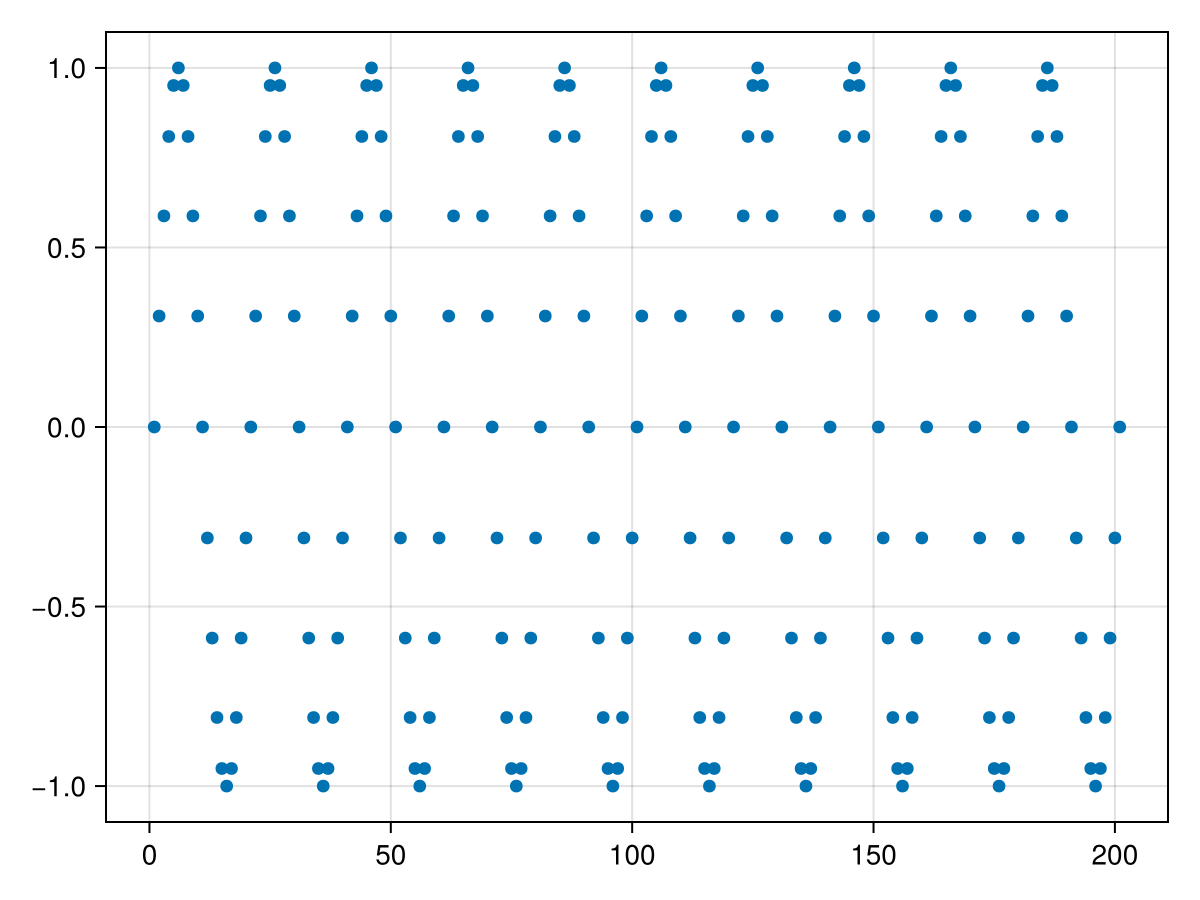

In [7]:
# Tracé de la fonction sinus 
sinus = plot(g)

In [8]:
save("C:/Users/lucie/Desktop/Sonification/fonction_sinus.png", sinus)

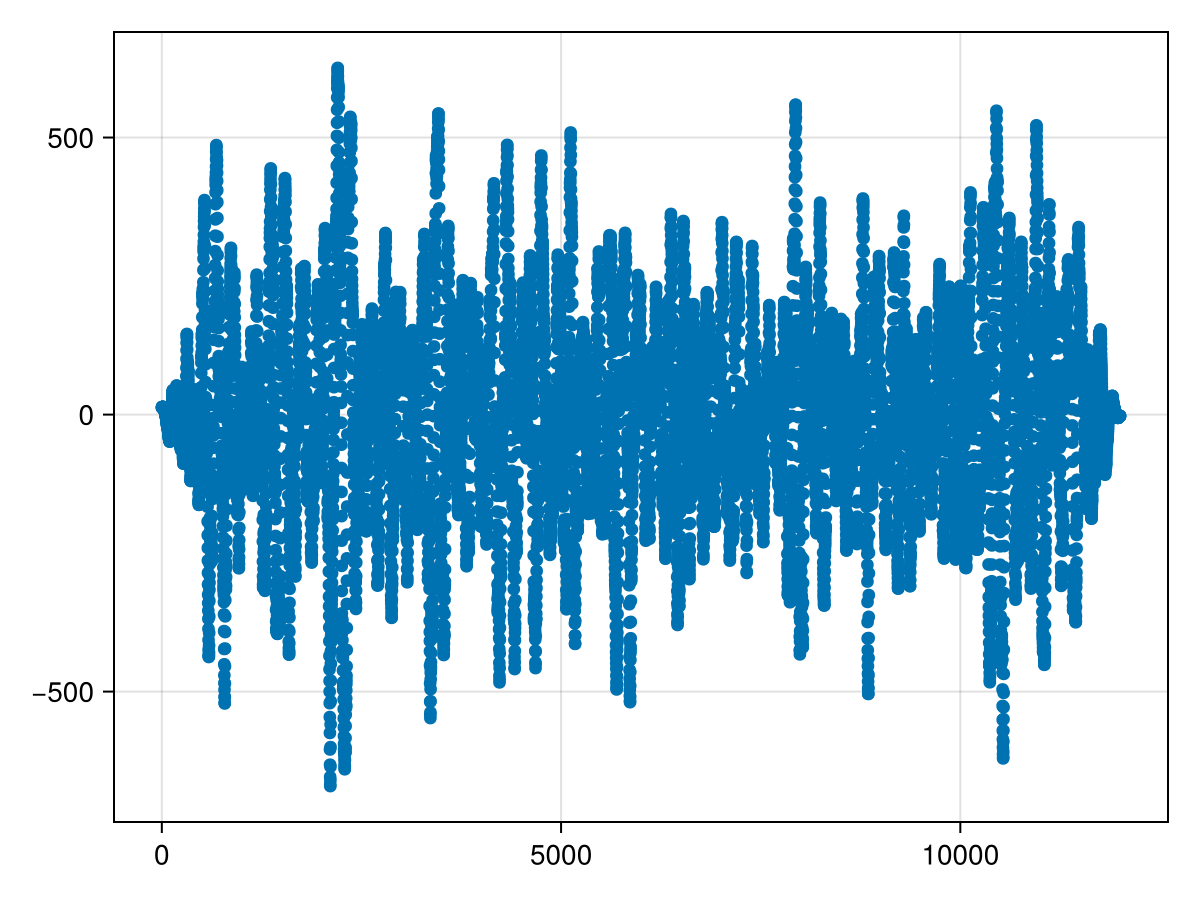

In [9]:
# Tracé du sismogramme en fonction du temps
x = traces[1].t
sismo = plot(x)

In [10]:
save("C:/Users/lucie/Desktop/Sonification/sismogramme.png", sismo)

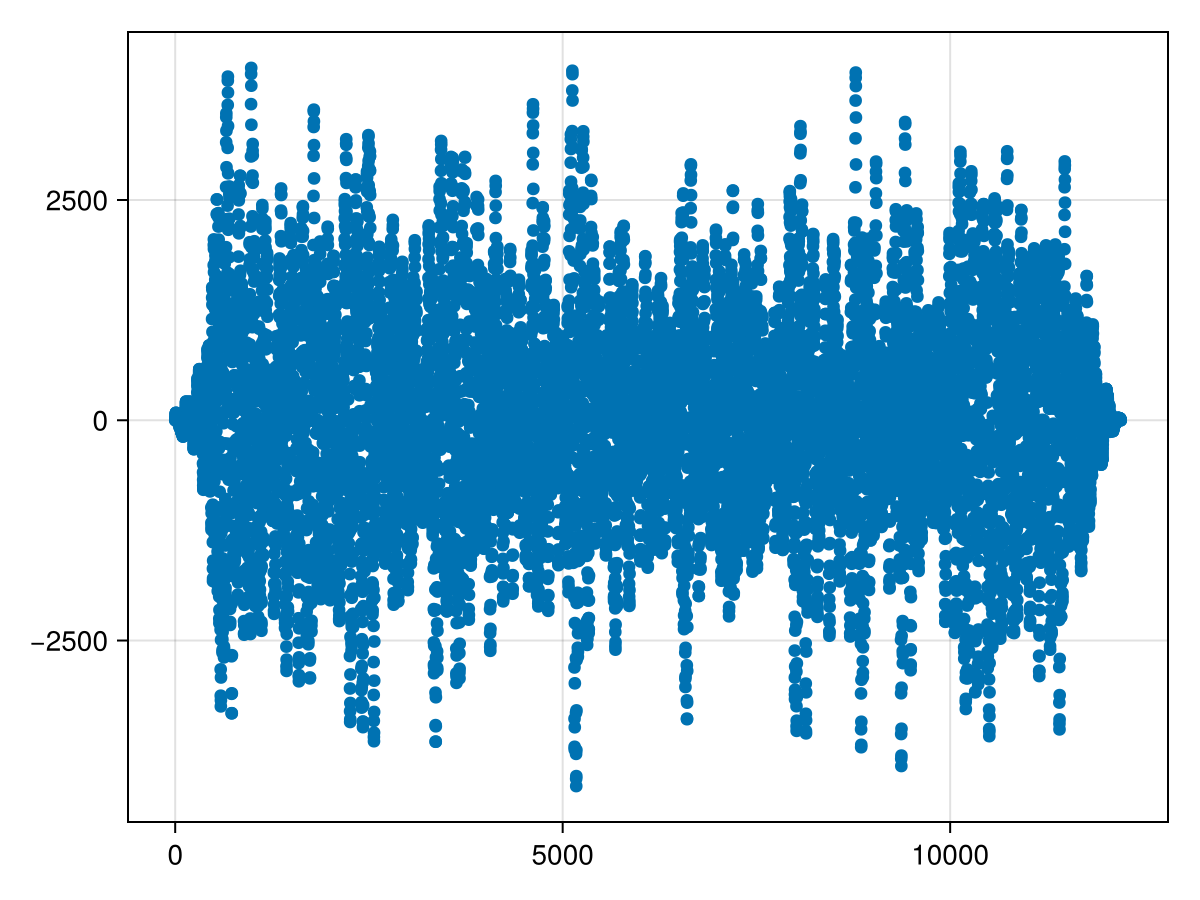

In [11]:
# Convolution du signal sinusoïdal avec le sismogramme
y = conv(x,g)
sortie = plot(y)

In [12]:
save("C:/Users/lucie/Desktop/Sonification/convolution.png", sortie)

In [13]:
#println(y)

In [ ]:
for i in y
    if i >= 3000
        play(s(t.(n.("C"), tuning=just)))
    elseif 2750 <= i < 3000
        play(s(t.(n.("D"), tuning=just)))
    elseif 2500 <= i < 2750
        play(s(t.(n.("E"), tuning=just)))
    elseif 2250 <= i < 2500
        play(s(t.(n.("F"), tuning=just)))
    elseif 2000 <= i < 2250
        play(s(t.(n.("G"), tuning=just)))
    elseif 1750 <= i < 2000
        play(s(t.(n.("A"), tuning=just)))
    elseif 1500 <= i < 1750
        play(s(t.(n.("B"), tuning=just)))
    elseif 1250 <= i < 1500
        play(s(t.(n.("C#"), tuning=just)))
    elseif 1000 <= i < 1250
        play(s(t.(n.("D#"), tuning=just)))
    elseif 750 <= i < 1000
        play(s(t.(n.("F#"), tuning=just)))
    elseif 500 <= i < 750
        play(s(t.(n.("G#"), tuning=just)))
    elseif 250 <= i < 500
        play(s(t.(n.("A#"), tuning=just)))
    elseif 0 <= i < 250
        play(s(t.(n.("B#"), tuning=just)))
    elseif -250 <= i < 0
        play(s(t.(n.("C"), tuning=just)))
    elseif -500 <= i < -250
        play(s(t.(n.("D"), tuning=just)))
    elseif -750 <= i < -500
        play(s(t.(n.("E"), tuning=just)))
    elseif -1000 <= i < - 750
        play(s(t.(n.("F"), tuning=just)))
    elseif -1250 <= i < -1000
        play(s(t.(n.("G"), tuning=just)))
    elseif -1500 <= i < -1250
        play(s(t.(n.("A"), tuning=just)))
    elseif -1750 <= i < -1500
        play(s(t.(n.("B"), tuning=just)))
    elseif -2000 <= i < -1750
        play(s(t.(n.("C#"), tuning=just)))
    elseif -2250 <= i < -2000
        play(s(t.(n.("D#"), tuning=just)))
    elseif -2500 <= i < -2250
        play(s(t.(n.("F#"), tuning=just)))
    elseif -2750 <= i < -2500
        play(s(t.(n.("G#"), tuning=just)))
    elseif -3000 <= i < -2750
        play(s(t.(n.("A#"), tuning=just)))
    else
        play(s(t.(n.("B#"), tuning=just)))
    end
end